In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
from merf import MERF

In [2]:
df_research_master = pl.read_csv("data/final.csv")

In [3]:
df_research_master["light"].sum()

1776

In [4]:
df_research_master = df_research_master.with_columns(
    pl.when((pl.col("hour").is_between(7, 9)) | (pl.col("hour").is_between(15, 17)))
    .then(1)
    .otherwise(0)
    .alias("is_school_peak")
)

In [5]:
sum_cols = [
    "total_accidents",
    "total_cycling_accidents",
    "car_conflict",
    "severity",
    "slick",
    "light",
    "intersection",
    "school_peak",
    "local_accidents",
]

mean_cols = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "bad_weather_ratio",
    "relative_sensor_age",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "inbound_push_ratio",
]


demo_cols = [
    col
    for col in df_research_master.columns
    if col.startswith("pct_") or col == "total_pop"
]

In [6]:
df_yearly = df_research_master.group_by(["gemeente", "year"]).agg(
    [pl.col(c).sum() for c in sum_cols]
    + [pl.col(c).mean() for c in mean_cols]
    + [pl.col(c).mean() for c in demo_cols]
)

In [7]:
df_yearly = df_yearly.with_columns(
    [
        (pl.col("total_accidents") / pl.col("total_hourly_flow")).alias(
            "accident_rate_per_flow"
        ),
        (pl.col("total_accidents") / pl.col("total_pop")).alias(
            "accident_rate_per_capita"
        ),
        (pl.col("severity") / pl.col("total_accidents")).alias("severity_index"),
    ]
)

In [8]:
df_yearly.head()

gemeente,year,total_accidents,total_cycling_accidents,car_conflict,severity,slick,light,intersection,school_peak,local_accidents,total_hourly_flow,avg_temp,avg_precip,avg_mun_wind,bad_weather_ratio,relative_sensor_age,avg_income_per_capita,prof_earner_ratio,avg_employment_rate,inbound_push_ratio,total_pop,pct_young_children,pct_school_kids,pct_uni_students,pct_young_profs,pct_senior_profs,pct_seniors,pct_male,pct_female,pct_belgian,pct_foreign,pct_single,pct_married,pct_widowed,pct_divorced,accident_rate_per_flow,accident_rate_per_capita,severity_index
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Kraainem""",2021,39,5,3,0,1,1,3,1,1,445.725694,10.467409,0.0,12.498378,0.064408,2.0,23555.846198,0.433946,0.700013,0.229319,13847.0,0.088395,0.138658,0.103633,0.142991,0.346934,0.179389,0.484437,0.515563,0.676464,0.323536,0.495414,0.391998,0.04232,0.070268,0.087498,0.002816,0.0
"""Tongeren""",2025,0,0,0,0,0,0,0,0,0,171.611111,12.548358,0.055673,10.432759,0.104718,3.0,25355.116935,0.624688,0.720713,0.501148,32459.0,0.06917,0.105732,0.079968,0.153992,0.348746,0.242392,0.493466,0.506534,0.913903,0.086097,0.446636,0.385432,0.064752,0.10318,0.0,0.0,NaN
"""Zele""",2024,90,39,23,7,12,4,16,11,2,604.111111,12.002278,0.100273,12.8688,0.136627,2.0,23839.063522,0.587866,0.751132,0.740315,21501.0,0.083252,0.117483,0.094693,0.172364,0.332357,0.199851,0.497884,0.502116,0.891307,0.108693,0.457514,0.400772,0.058881,0.082833,0.148979,0.004186,0.077778
"""Brecht""",2025,0,0,0,0,0,0,0,0,0,539.972222,12.81338,0.053178,11.904904,0.089184,3.0,28352.576208,0.589632,0.724252,0.966336,30664.0,0.079018,0.104846,0.082735,0.163514,0.34278,0.227107,0.498891,0.501109,0.929559,0.070441,0.451604,0.415993,0.051624,0.080779,0.0,0.0,NaN
"""Deinze""",2023,124,42,25,6,15,7,26,19,0,682.284722,12.159162,0.110651,14.147687,0.152623,0.0,26662.619885,0.592158,0.757155,0.521952,44930.0,0.077721,0.112597,0.081015,0.16913,0.344202,0.215335,0.491787,0.508213,0.941131,0.058869,0.461451,0.395415,0.059359,0.083775,0.181742,0.00276,0.048387


In [ ]:
# previous year features
df_features = df_yearly.sort(["gemeente", "year"]).with_columns(
    [
        pl.col("severity")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_severe_count"),
        pl.col("light")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_dark_count"),
        pl.col("local_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_local_accidents"),
        pl.col("school_peak")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_school_accidents"),
        pl.col("slick")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_slick_accidents"),
        pl.col("car_conflict")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_carconflict_accidents"),
        pl.col("intersection")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_int_accidents"),
        pl.col("total_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_accidents"),
        pl.col("total_cycling_accidents")
        .shift(1)
        .over("gemeente")
        .fill_null(0)
        .alias("prev_year_total_cyc_accidents"),
        pl.col("total_cycling_accidents")
        .mean()
        .over("gemeente")
        .alias("historical_town_avg"),
    ]
)


In [10]:
df_features = df_features.with_columns(
    [
        (
            pl.col("pct_school_kids")
            * pl.col("total_pop")
            / pl.col("total_hourly_flow")
        ).alias("school_zone_exposure"),
        (pl.col("prev_year_total_accidents") / (pl.col("total_pop") / 1000)).alias(
            "risk_per_1k_residents"
        ),
        (pl.col("avg_mun_wind") * pl.col("avg_precip")).alias("weather_severity_index"),
        (pl.col("total_hourly_flow") / pl.col("total_pop")).alias("flow_density"),
    ]
)

In [11]:
df_features = df_features.sort(["gemeente", "year"]).with_columns(
    pl.col("total_cycling_accidents")
    .backward_fill()
    .over("gemeente")
    .alias("smoothed_target")
)

In [12]:
upper_limit = df_features["total_hourly_flow"].quantile(0.99)
df_features = df_features.with_columns(
    pl.col("total_hourly_flow").clip(upper_bound=upper_limit)
)

In [ ]:
features = [
    "total_hourly_flow",
    "avg_temp",
    "avg_precip",
    "avg_mun_wind",
    "avg_income_per_capita",
    "prof_earner_ratio",
    "avg_employment_rate",
    "total_pop",
    "pct_young_children",
    "pct_school_kids",
    "pct_uni_students",
    "pct_young_profs",
    "pct_senior_profs",
    "pct_seniors",
    "pct_male",
    "pct_belgian",
    "pct_single",
    "pct_married",
    "pct_widowed",
    "prev_year_severe_count",
    "prev_year_dark_count",
    "prev_year_total_accidents",
    "prev_year_school_accidents",
    "prev_year_slick_accidents",
    "prev_year_local_accidents",
    "prev_year_total_cyc_accidents",
    "historical_town_avg",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
    "school_zone_exposure",
    "risk_per_1k_residents",
    "flow_density",
    "bad_weather_ratio",
    "relative_sensor_age",
    "inbound_push_ratio",
]


In [14]:
df_features = (
    df_features.with_columns(
        [
            pl.when(pl.col(col).is_infinite())
            .then(0.0)
            .otherwise(pl.col(col))
            .alias(col)
            for col in features
        ]
    )
    .fill_null(0.0)
    .with_columns([pl.col(col).cast(pl.Float32) for col in features])
)

In [15]:
train_df = df_features.filter(pl.col("year").is_in([2021, 2022, 2023]))
val_df = df_features.filter(pl.col("year") == 2024)
test_df = df_features.filter(pl.col("year") == 2025)

In [16]:
X_train = train_df.select(features).to_pandas()
y_train = train_df.select("smoothed_target").to_pandas().values.flatten()

In [17]:
y_train

array([ 68., 109., 105.,  19.,  41.,  22.,  33.,   7.,  10.,  10.,   4.,
        14.,  26.,  15.,  15.,  18.,   5.,  14.,  27.,  74.,  19.,  17.,
        22.,  50.,  55.,  79.,  19.,  29.,  31.,  35.,  30., 180., 227.,
       212.,  20.,  42.,  26.,  81.,  10.,  16.,  31.,  48.,  45.,  55.,
        35.,  46.,  78., 131.,  82., 494., 632., 538.,  13.,  30.,  12.,
        30.,  96.,   3.,   2.,  29.,  45.,  35.,  14.,  24.,  25.,  47.,
         7.,  12.,  35.,  74.,  74.,  29.,  41.,   7.,  13., 106., 143.,
       122.,   5.,   1.,   1.,  15.,  11., 141., 211.,  28.,  67.,  13.,
        20.,  74.,  39.,  36.,   3.,  11.,  18.,  18.,  20.,  28.,  10.,
        21.,  74., 118.,  10.,  14.,   8.,   9.,  12.,   5.,   5.,   3.,
        20.,  15.,  17.,  22.,  25.,  84.,  83.,  80.,  11.,  10.,  37.,
        55.,   1.,   2.,   2.,   5.,  23.,  27.,  29.,  22.,  25.,  10.,
        21.,  48.,  48.,   4.,  11.,  13.,  28.,  20.,  30.,   6.,  20.,
        12.,  11.,  41.,  10.,  21.])

In [18]:
X_val = val_df.select(features).to_pandas()
y_val = val_df.select("smoothed_target").to_pandas().values.flatten()

In [19]:
y_val

array([105.,  37.,  41.,   7.,   7.,  35.,  18.,   9.,  58.,  16.,  72.,
        21.,  37., 203.,  36.,  70.,   6.,  30.,  53.,  52.,  93., 550.,
        30.,  37.,  89.,   2.,  44.,  14.,  45.,   7.,  36.,  56.,  30.,
        10., 122.,   3.,   5., 208.,  53.,  13., 104.,  32.,   9.,  18.,
        21.,  12., 125.,  18.,  22.,  13.,   9.,  15.,  15.,  91.,  13.,
        25.,   5.,  12.,  19.,  26.,  17.,  36.,   4.,  17.,  31.,  18.,
        39.,  17.])

In [20]:
X_test = test_df.select(features).to_pandas()

In [21]:
pop_weights = (train_df["total_pop"] / train_df["total_pop"].mean()).to_numpy()

In [22]:
X_train_scaled = StandardScaler().fit_transform(X_train)
X_val_scaled = StandardScaler().fit_transform(X_val)
X_test_scaled = StandardScaler().fit_transform(X_test)

In [23]:
def plot_lorenz_curve(y_true, y_pred, label, fig=None, ax=None):
    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = plt.gca()

    y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()

    df_eval = pd.DataFrame({"true": y_true_flat, "pred": y_pred_flat}).sort_values(
        "pred"
    )

    cum_true = np.cumsum(df_eval["true"]) / np.sum(df_eval["true"])
    cum_pop = np.arange(1, len(cum_true) + 1) / len(cum_true)

    area_under_curve = np.trapezoid(cum_true, cum_pop)
    gini = 1 - 2 * area_under_curve

    ax.plot(cum_pop, cum_true, label=f"{label} (Gini: {gini:.3f})")
    return gini

In [24]:
print(
    f"Train: {X_train.shape}  ({train_df['gemeente'].n_unique()} municipalities, 2021 - 2023)\n"
)
print(f"Val: {X_val.shape}   ({val_df['gemeente'].n_unique()} municipalities, 2024)\n")
print(
    f"Test: {X_test.shape}  ({test_df['gemeente'].n_unique()} municipalities, 2025)\n"
)
print(f"Features: {len(features)}")

Train: (148, 35)  (68 municipalities, 2021 - 2023)

Val: (68, 35)   (68 municipalities, 2024)

Test: (68, 35)  (68 municipalities, 2025)

Features: 35


In [25]:
(val_df["gemeente"] == "Antwerpen").sum()

0

In [26]:
missing_gemeentes = (
    val_df.join(test_df, on="gemeente", how="anti").select("gemeente").unique()
)

print(missing_gemeentes)

shape: (0, 1)
┌──────────┐
│ gemeente │
│ ---      │
│ str      │
╞══════════╡
└──────────┘


# Model 1
## Two Stage Model

for this model, I'm dividing them into two distinct categories. low risk ones, and high risk ones. threshold is set at the median

In [27]:
median_threshold = np.median(y_train)
print(f"Median threshold for low/high split: {median_threshold:.2f}")

Median threshold for low/high split: 23.50


In [28]:
y_train_tier = (y_train > median_threshold).astype(int)  # 0 = low, 1 = high
y_val_tier = (y_val > median_threshold).astype(int)

In [29]:
print(
    f"Train — Low risk: {(y_train_tier==0).sum()}, High risk: {(y_train_tier==1).sum()}"
)
print(
    f"Val   — Low risk: {(y_val_tier==0).sum()},   High risk: {(y_val_tier==1).sum()}"
)

Train — Low risk: 74, High risk: 74
Val   — Low risk: 33,   High risk: 35


In [30]:
scaler_two_stage = StandardScaler()
X_train_1 = scaler_two_stage.fit_transform(X_train)
X_val_1 = scaler_two_stage.transform(X_val)
X_test_1 = scaler_two_stage.transform(X_test)

In [31]:
stage1_model = LogisticRegression(max_iter=1000, C=0.5, random_state=7)
stage1_model.fit(X_train_1, y_train_tier, sample_weight=pop_weights)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

with `stage1_model` I'm trying to define whether it's gonna be low or high risk

In [32]:
p_high_val = stage1_model.predict_proba(X_val_1)[:, 1]
p_high_test = stage1_model.predict_proba(X_test_1)[:, 1]

In [33]:
low_mask = y_train_tier == 0
high_mask = y_train_tier == 1

In [34]:
model_low = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42,
)

In [35]:
model_low.fit(
    X_train[low_mask],
    y_train[low_mask],
    sample_weight=pop_weights[low_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [36]:
model_high = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    random_state=42,
)

In [37]:
model_high.fit(
    X_train[high_mask],
    y_train[high_mask],
    sample_weight=pop_weights[high_mask],
    verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [38]:
val_preds_1 = p_high_val * model_high.predict(X_val) + (
    1 - p_high_val
) * model_low.predict(X_val)

In [39]:
test_preds_1 = p_high_test * model_high.predict(X_test) + (
    1 - p_high_test
) * model_low.predict(X_test)

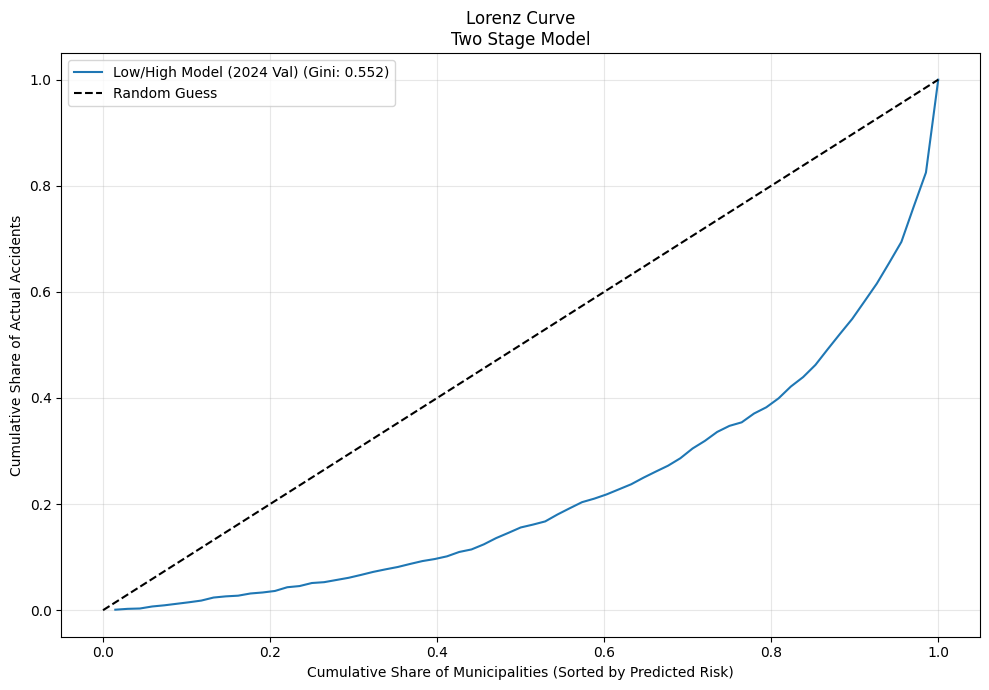

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_1, "Low/High Model (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nTwo Stage Model")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

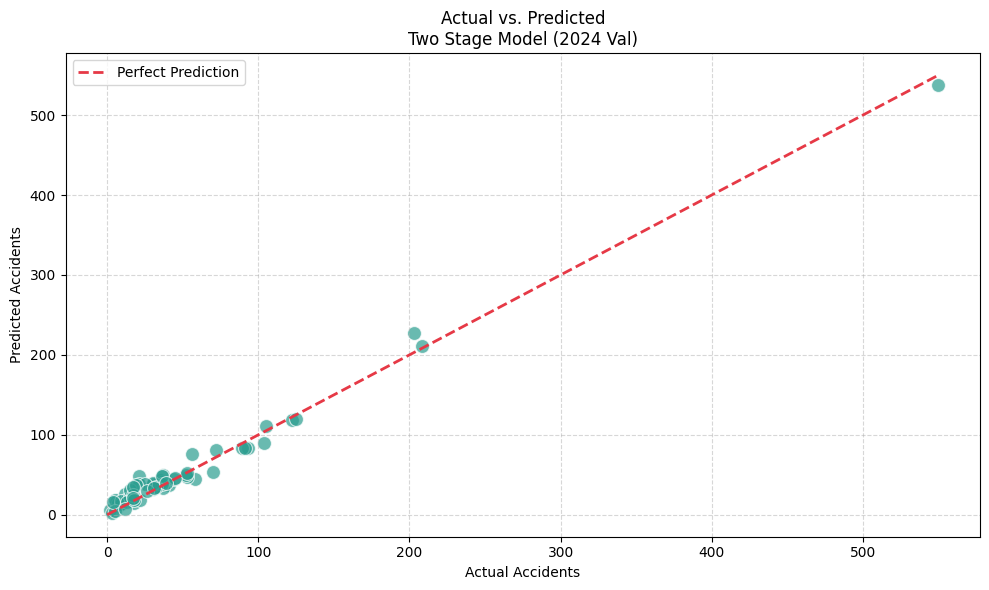

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_val, y=val_preds_1, alpha=0.7, color="#2A9D8F", s=100, ax=ax)

max_val = max(y_val.max(), val_preds_1.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nTwo Stage Model (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)


fig.tight_layout()

In [42]:
split_model_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_split_model", values=test_preds_1)
)

In [43]:
print("\nTop 10 High-Risk Municipalities — Two Stage Model (2025):")
print(split_model_results_2025.sort("pred_split_model", descending=True).head(10))


Top 10 High-Risk Municipalities — Two Stage Model (2025):
shape: (10, 3)
┌──────────┬────────┬──────────────────┐
│ gemeente ┆ year   ┆ pred_split_model │
│ ---      ┆ ---    ┆ ---              │
│ str      ┆ f64    ┆ f64              │
╞══════════╪════════╪══════════════════╡
│ Gent     ┆ 2025.0 ┆ 617.934814       │
│ Brugge   ┆ 2025.0 ┆ 218.385935       │
│ Leuven   ┆ 2025.0 ┆ 202.699997       │
│ Kortrijk ┆ 2025.0 ┆ 138.4725         │
│ Mechelen ┆ 2025.0 ┆ 118.79592        │
│ Aalst    ┆ 2025.0 ┆ 115.425427       │
│ Genk     ┆ 2025.0 ┆ 97.636559        │
│ Hasselt  ┆ 2025.0 ┆ 95.877142        │
│ Lokeren  ┆ 2025.0 ┆ 91.036956        │
│ Oostende ┆ 2025.0 ┆ 86.045085        │
└──────────┴────────┴──────────────────┘


# Model 2
## Catboost

In [44]:
train_pool = Pool(X_train, label=y_train, weight=pop_weights)
val_pool = Pool(X_val, label=y_val)
test_pool = Pool(X_test)

In [45]:
model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.02,
    depth=8,
    loss_function="Tweedie:variance_power=1.5",
    eval_metric="RMSE",
    random_seed=15,
    early_stopping_rounds=50,
    verbose=100,
)

In [46]:
model_cat.fit(train_pool, eval_set=val_pool)

0:	learn: 220.7013001	test: 87.2302849	best: 87.2302849 (0)	total: 72.8ms	remaining: 1m 12s
100:	learn: 218.6261195	test: 85.8177325	best: 85.8177325 (100)	total: 552ms	remaining: 4.91s
200:	learn: 217.6643425	test: 85.2888933	best: 85.2888933 (200)	total: 1s	remaining: 4s
300:	learn: 217.4856968	test: 85.2042562	best: 85.2042562 (300)	total: 1.49s	remaining: 3.46s
400:	learn: 217.4579007	test: 85.1951693	best: 85.1950807 (387)	total: 1.89s	remaining: 2.83s
500:	learn: 217.4540496	test: 85.1947969	best: 85.1941483 (457)	total: 2.31s	remaining: 2.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 85.19414831
bestIteration = 457

Shrink model to first 458 iterations.


CatBoostRegressor(depth=8, early_stopping_rounds=50, eval_metric='RMSE', iterations=1000, learning_rate=0.02, loss_function='Tweedie:variance_power=1.5', random_seed=15, verbose=100)

In [47]:
feat_importance = pd.Series(
    model_cat.get_feature_importance(), index=features
).sort_values(
    ascending=False
)  # type: ignore

In [48]:
feat_importance

historical_town_avg                12.932427
total_pop                           7.556392
pct_uni_students                    4.409651
pct_senior_profs                    3.982767
total_hourly_flow                   3.914579
pct_school_kids                     3.769671
pct_widowed                         3.676193
pct_single                          3.314357
pct_married                         3.267375
flow_density                        3.197749
school_zone_exposure                3.172428
pct_young_profs                     3.001947
avg_employment_rate                 2.955391
prof_earner_ratio                   2.709479
avg_mun_wind                        2.695286
inbound_push_ratio                  2.646182
avg_income_per_capita               2.619953
pct_male                            2.613145
avg_temp                            2.562055
avg_precip                          2.512081
pct_belgian                         2.234692
pct_seniors                         2.150302
bad_weathe

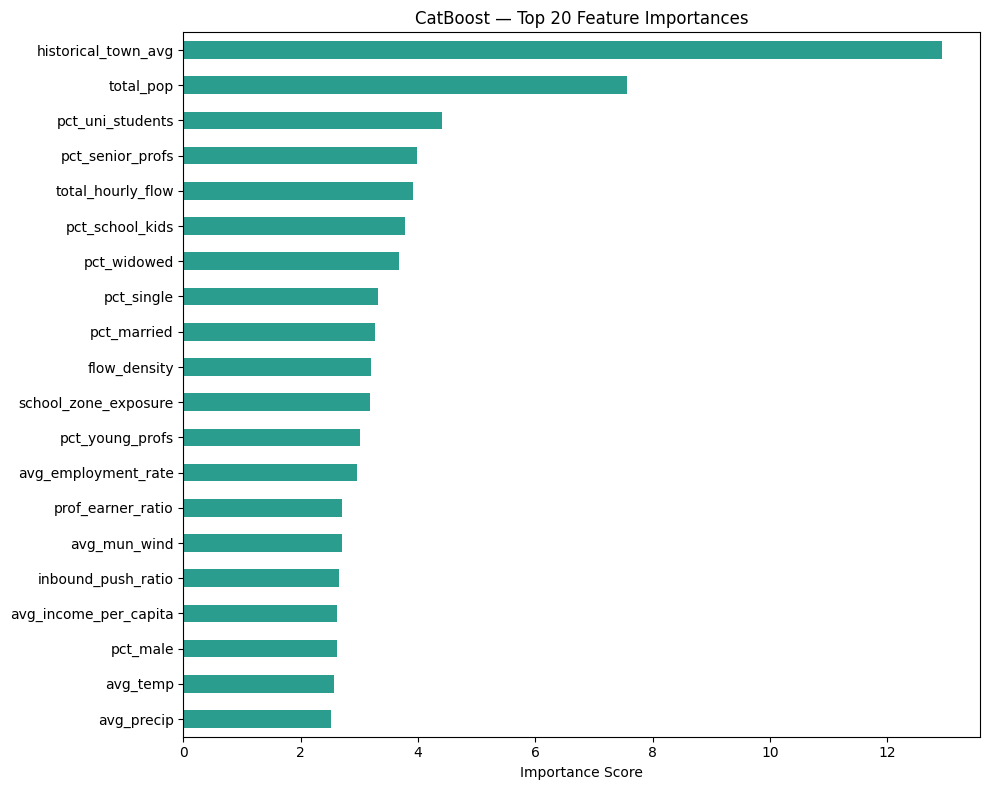

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))

feat_importance.head(20).plot(kind="barh", color="#2A9D8F", ax=ax)
ax.invert_yaxis()

ax.set_title("CatBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance Score")

fig.tight_layout()

In [50]:
val_preds_cat = model_cat.predict(val_pool)

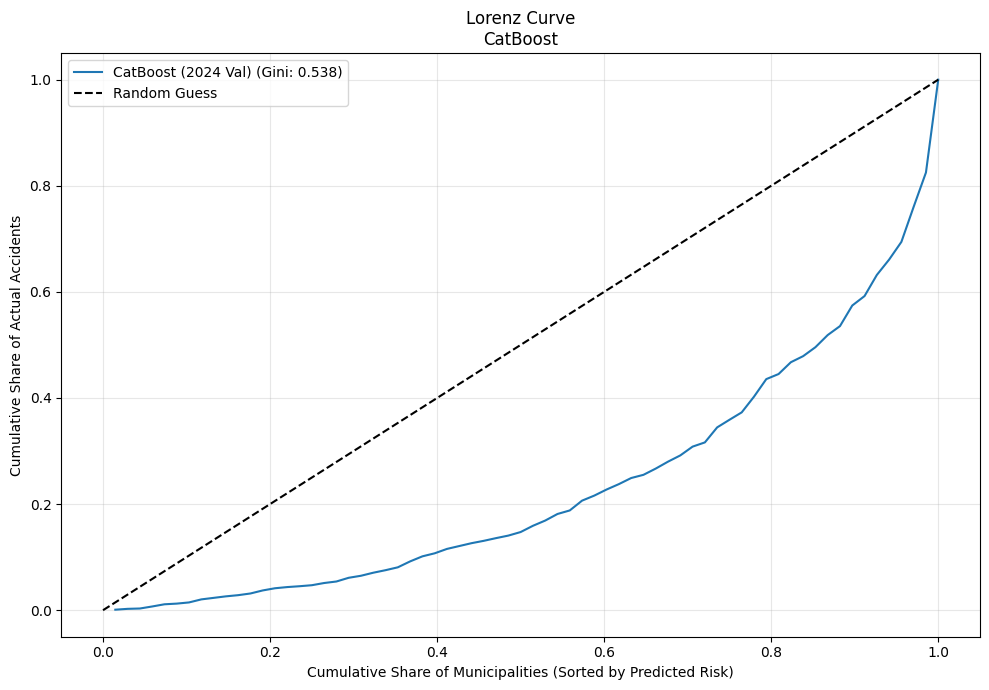

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_lorenz_curve(y_val, val_preds_cat, "CatBoost (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")

ax.set_title("Lorenz Curve\nCatBoost")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

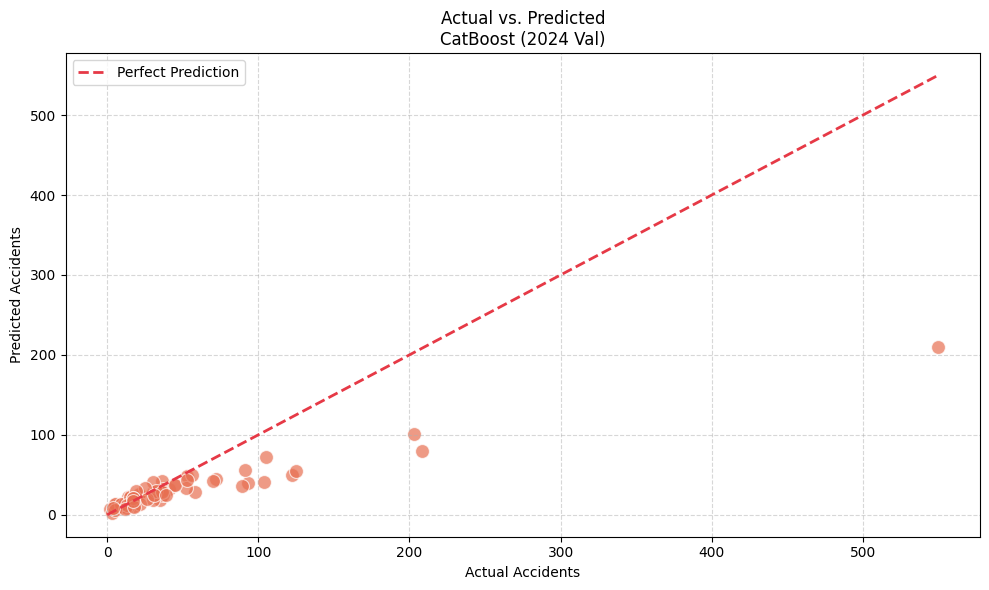

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x=y_val, y=val_preds_cat, alpha=0.7, color="#E76F51", s=100, ax=ax)

max_val = max(y_val.max(), val_preds_cat.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nCatBoost (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

In [53]:
test_preds_cat = model_cat.predict(test_pool)

In [54]:
cat_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_catboost", values=test_preds_cat)
)

In [55]:
print("\nTop 10 High-Risk Municipalities — CatBoost (2025):")
print(cat_results_2025.sort("pred_catboost", descending=True).head(10))


Top 10 High-Risk Municipalities — CatBoost (2025):
shape: (10, 3)
┌────────────┬────────┬───────────────┐
│ gemeente   ┆ year   ┆ pred_catboost │
│ ---        ┆ ---    ┆ ---           │
│ str        ┆ f64    ┆ f64           │
╞════════════╪════════╪═══════════════╡
│ Brugge     ┆ 2025.0 ┆ 61.320528     │
│ Ieper      ┆ 2025.0 ┆ 58.09135      │
│ Gent       ┆ 2025.0 ┆ 40.969383     │
│ Oostende   ┆ 2025.0 ┆ 38.27354      │
│ Kortrijk   ┆ 2025.0 ┆ 37.63503      │
│ Genk       ┆ 2025.0 ┆ 37.609195     │
│ Beveren    ┆ 2025.0 ┆ 33.789938     │
│ Leuven     ┆ 2025.0 ┆ 33.603331     │
│ Izegem     ┆ 2025.0 ┆ 33.335878     │
│ Brasschaat ┆ 2025.0 ┆ 33.034347     │
└────────────┴────────┴───────────────┘


# Model 3
## XGBoost

In [56]:
dtrain_xgb = xgb.DMatrix(X_train, label=y_train, weight=pop_weights)
dval_xgb = xgb.DMatrix(X_val, label=y_val)
dtest_xgb = xgb.DMatrix(X_test)

In [57]:
xgb_params = {
    "objective": "count:poisson",
    "eval_metric": "mae",
    "learning_rate": 0.02,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "seed": 25,
}

In [58]:
model_xgb = xgb.train(
    xgb_params,
    dtrain_xgb,
    num_boost_round=1000,
    evals=[(dtrain_xgb, "train"), (dval_xgb, "val")],
    early_stopping_rounds=50,
    verbose_eval=100,
)

[0]	train-mae:127.13105	val-mae:100.03379
[100]	train-mae:51.46941	val-mae:40.14515
[200]	train-mae:19.41634	val-mae:18.33972
[300]	train-mae:7.55608	val-mae:9.98855
[400]	train-mae:3.19163	val-mae:7.69665
[500]	train-mae:1.65434	val-mae:6.90823
[600]	train-mae:1.14817	val-mae:6.65889
[700]	train-mae:0.97637	val-mae:6.58713
[800]	train-mae:0.94635	val-mae:6.57579
[827]	train-mae:0.94256	val-mae:6.57425


In [59]:
feat_imp_xgb = pd.Series(
    model_xgb.get_score(importance_type="gain"), name="gain"
).sort_values(ascending=False)

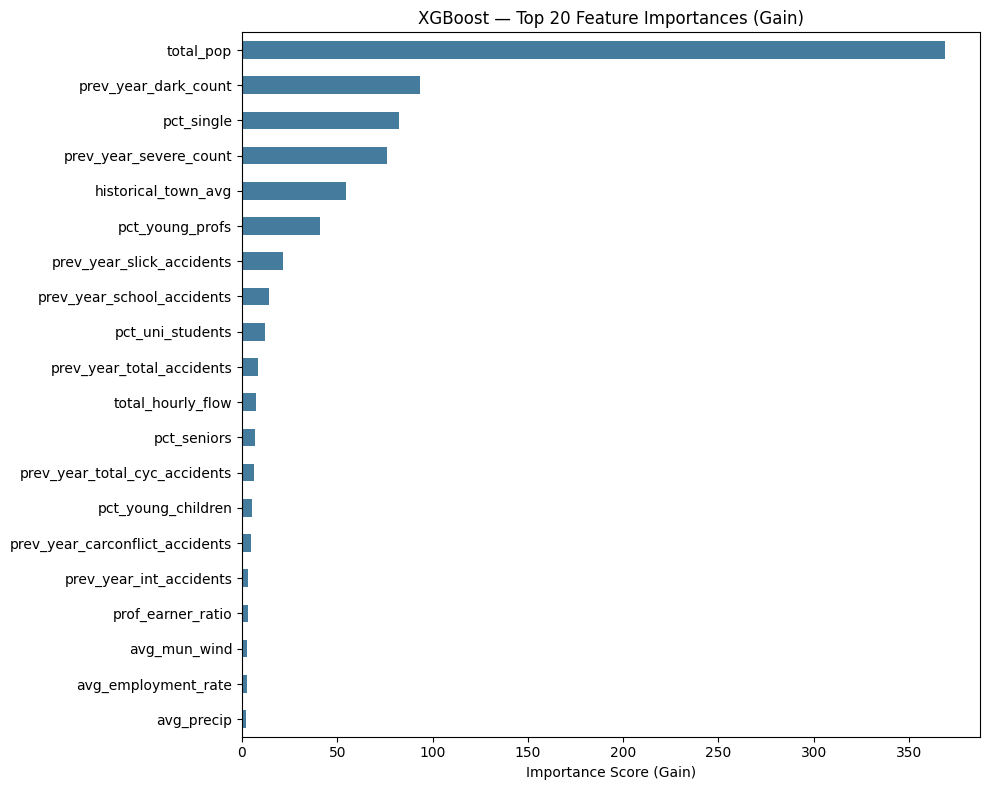

In [60]:
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_xgb.head(20).plot(kind="barh", color="#457B9D", ax=ax)
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 Feature Importances (Gain)")
ax.set_xlabel("Importance Score (Gain)")
fig.tight_layout()

In [61]:
val_preds_xgb = model_xgb.predict(dval_xgb)

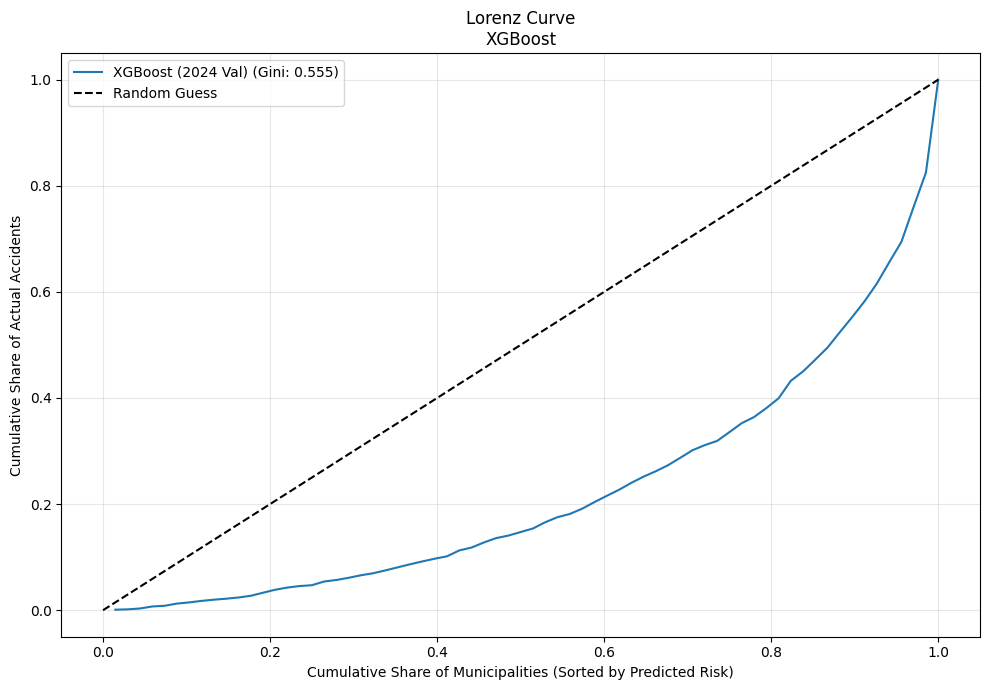

In [62]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title("Lorenz Curve\nXGBoost")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

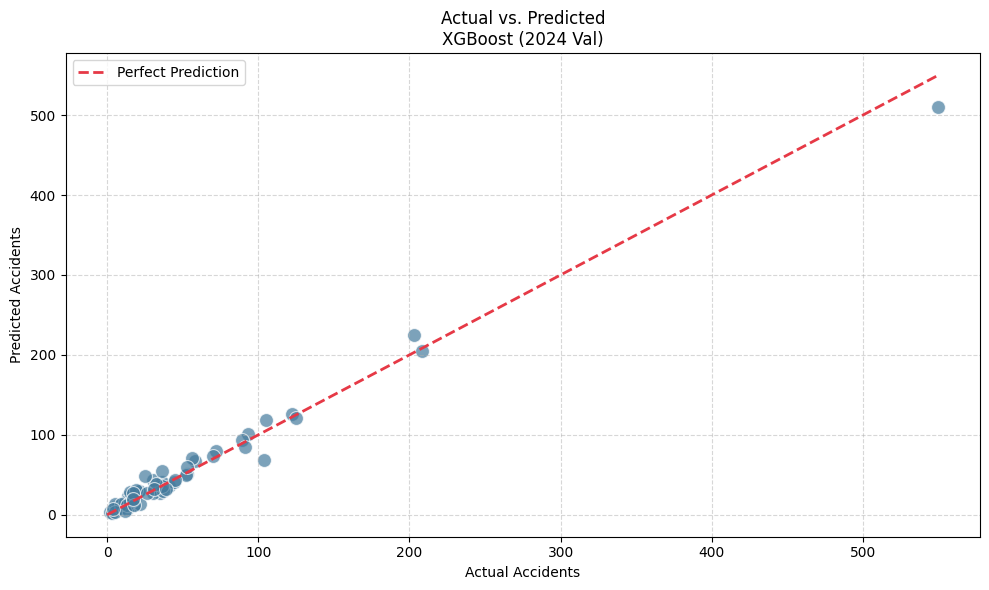

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=y_val, y=val_preds_xgb, alpha=0.7, color="#457B9D", s=100, ax=ax)
max_val = max(y_val.max(), val_preds_xgb.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)
ax.set_title("Actual vs. Predicted\nXGBoost (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()

In [64]:
test_preds_xgb = model_xgb.predict(dtest_xgb)
xgb_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_xgb", values=test_preds_xgb)
)

In [65]:
print("\nTop 10 High-Risk Municipalities — XGBoost (2025):")
print(xgb_results_2025.sort("pred_xgb", descending=True).head(10))


Top 10 High-Risk Municipalities — XGBoost (2025):
shape: (10, 3)
┌──────────┬────────┬────────────┐
│ gemeente ┆ year   ┆ pred_xgb   │
│ ---      ┆ ---    ┆ ---        │
│ str      ┆ f64    ┆ f32        │
╞══════════╪════════╪════════════╡
│ Gent     ┆ 2025.0 ┆ 436.921021 │
│ Brugge   ┆ 2025.0 ┆ 223.022537 │
│ Leuven   ┆ 2025.0 ┆ 212.855362 │
│ Kortrijk ┆ 2025.0 ┆ 136.067078 │
│ Mechelen ┆ 2025.0 ┆ 133.056168 │
│ Aalst    ┆ 2025.0 ┆ 128.896683 │
│ Hasselt  ┆ 2025.0 ┆ 111.350479 │
│ Lokeren  ┆ 2025.0 ┆ 95.661537  │
│ Oostende ┆ 2025.0 ┆ 94.697334  │
│ Genk     ┆ 2025.0 ┆ 94.265465  │
└──────────┴────────┴────────────┘


# Model 4
## MERF

In [66]:
X_train_merf = train_df.select(features).to_pandas()
y_train_merf = train_df.select("smoothed_target").to_pandas().values.flatten()
clusters_train = train_df["gemeente"].to_pandas()
Z_train = np.ones((len(X_train_merf), 1))

In [67]:
X_val_merf = val_df.select(features).to_pandas()
y_val_merf = val_df.select("smoothed_target").to_pandas().values.flatten()
clusters_val = val_df["gemeente"].to_pandas()
Z_val = np.ones((len(X_val_merf), 1))

In [68]:
X_test_merf = test_df.select(features).to_pandas()
clusters_test = test_df["gemeente"].to_pandas()
Z_test = np.ones((len(X_test_merf), 1))

In [69]:
model_merf = MERF(max_iterations=30)
model_merf.fit(X_train_merf, Z_train, clusters_train, y_train_merf)

INFO     [merf.py:307] Training GLL is 1051.5714058704075 at iteration 1.
INFO     [merf.py:307] Training GLL is 1062.6609423033613 at iteration 2.
INFO     [merf.py:307] Training GLL is 1108.4767924072069 at iteration 3.
INFO     [merf.py:307] Training GLL is 1125.1996888844378 at iteration 4.
INFO     [merf.py:307] Training GLL is 1158.6588377154335 at iteration 5.
INFO     [merf.py:307] Training GLL is 1162.0398482241078 at iteration 6.
INFO     [merf.py:307] Training GLL is 1170.1658917550872 at iteration 7.
INFO     [merf.py:307] Training GLL is 1183.794883771611 at iteration 8.
INFO     [merf.py:307] Training GLL is 1199.9428413116577 at iteration 9.
INFO     [merf.py:307] Training GLL is 1207.6975433072691 at iteration 10.
INFO     [merf.py:307] Training GLL is 1218.6157814690623 at iteration 11.
INFO     [merf.py:307] Training GLL is 1232.7302307232164 at iteration 12.
INFO     [merf.py:307] Training GLL is 1243.1881481725611 at iteration 13.
INFO     [merf.py:307] Training GLL

In [70]:
val_preds_merf = model_merf.predict(X_val_merf, Z_val, clusters_val)

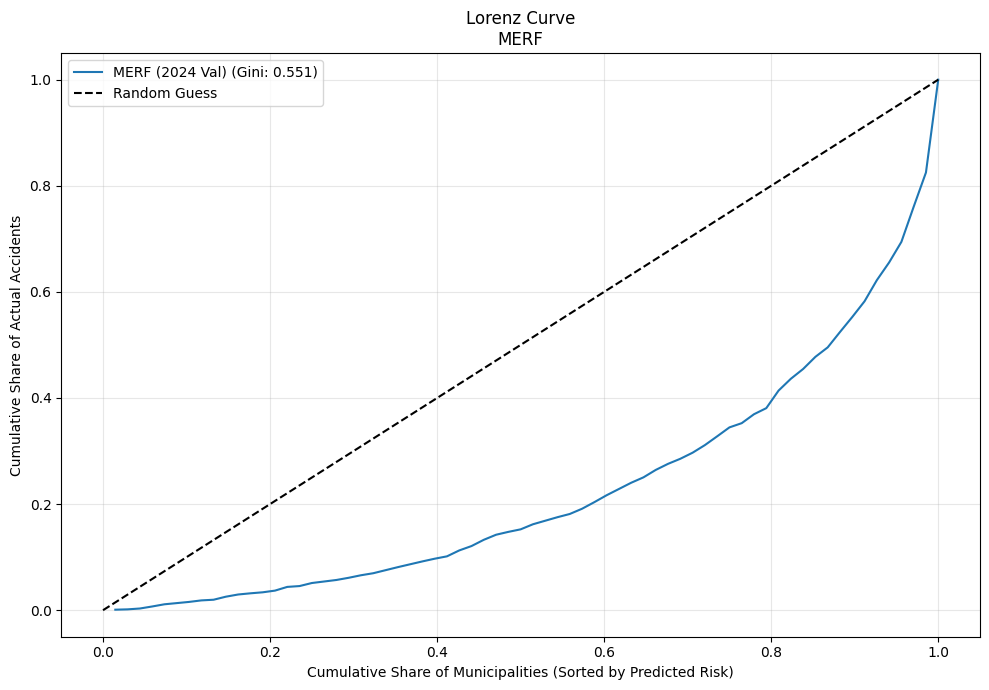

In [71]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF (2024 Val)", fig=fig, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")

ax.set_title("Lorenz Curve\nMERF")
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

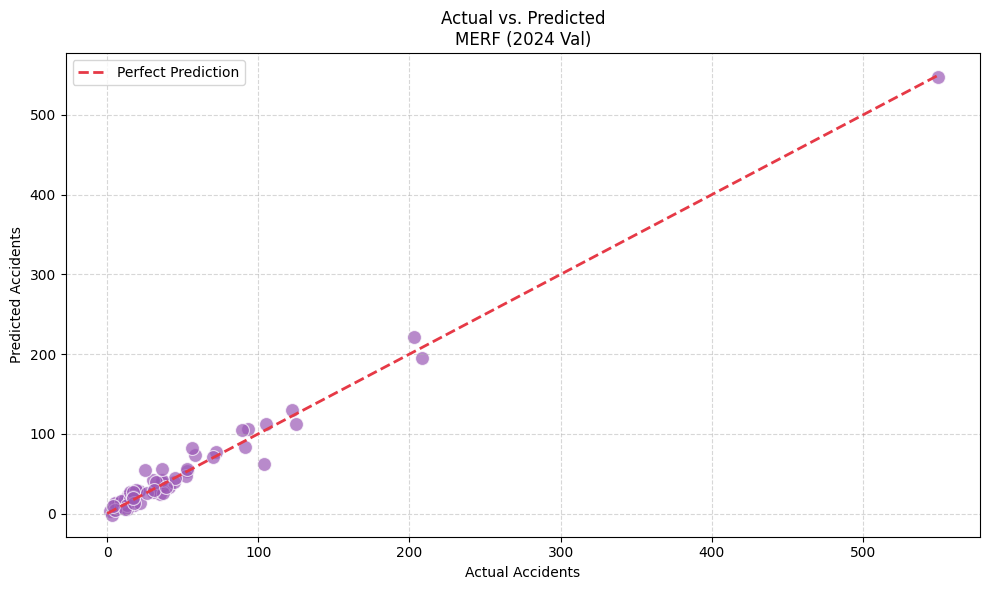

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x=y_val_merf, y=val_preds_merf, alpha=0.7, color="#9b59b6", s=100, ax=ax
)

max_val = max(y_val_merf.max(), val_preds_merf.max())
ax.plot(
    [0, max_val],
    [0, max_val],
    "--",
    color="#E63946",
    linewidth=2,
    label="Perfect Prediction",
)

ax.set_title("Actual vs. Predicted\nMERF (2024 Val)")
ax.set_xlabel("Actual Accidents")
ax.set_ylabel("Predicted Accidents")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

In [73]:
test_preds_merf = model_merf.predict(X_test_merf, Z_test, clusters_test)

merf_results_2025 = test_df.select(["gemeente", "year"]).with_columns(
    pl.Series(name="pred_merf", values=test_preds_merf)
)

In [74]:
print("\nTop 10 High-Risk Municipalities — MERF (2025):")
print(merf_results_2025.sort("pred_merf", descending=True).head(10))


Top 10 High-Risk Municipalities — MERF (2025):
shape: (10, 3)
┌──────────┬────────┬────────────┐
│ gemeente ┆ year   ┆ pred_merf  │
│ ---      ┆ ---    ┆ ---        │
│ str      ┆ f64    ┆ f64        │
╞══════════╪════════╪════════════╡
│ Gent     ┆ 2025.0 ┆ 559.2567   │
│ Brugge   ┆ 2025.0 ┆ 214.826247 │
│ Leuven   ┆ 2025.0 ┆ 202.876656 │
│ Kortrijk ┆ 2025.0 ┆ 131.89031  │
│ Mechelen ┆ 2025.0 ┆ 114.016973 │
│ Aalst    ┆ 2025.0 ┆ 113.829674 │
│ Hasselt  ┆ 2025.0 ┆ 107.317419 │
│ Genk     ┆ 2025.0 ┆ 98.508795  │
│ Oostende ┆ 2025.0 ┆ 87.466539  │
│ Lokeren  ┆ 2025.0 ┆ 81.953393  │
└──────────┴────────┴────────────┘


# Model Comparison

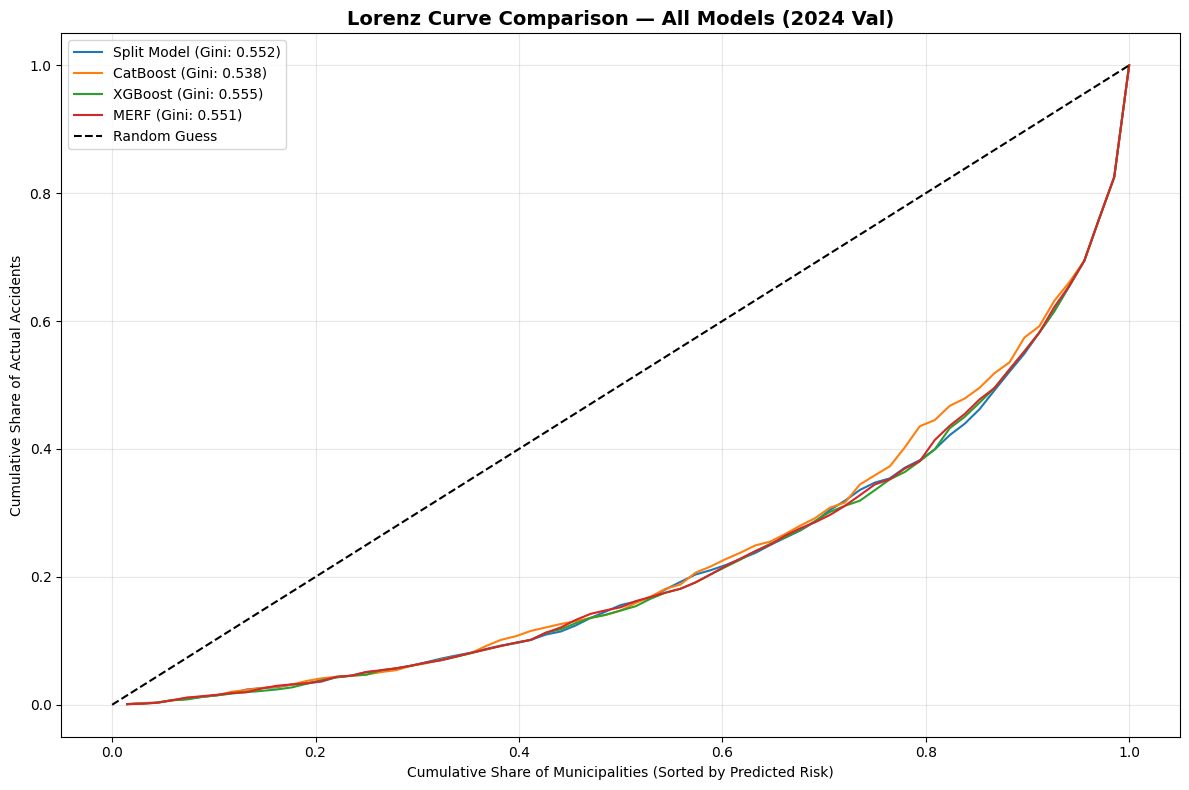

In [75]:
fig, ax = plt.subplots(figsize=(12, 8))

plot_lorenz_curve(y_val, val_preds_1, "Split Model", fig=fig, ax=ax)
plot_lorenz_curve(y_val, val_preds_cat, "CatBoost", fig=fig, ax=ax)
plot_lorenz_curve(y_val, val_preds_xgb, "XGBoost", fig=fig, ax=ax)
plot_lorenz_curve(y_val_merf, val_preds_merf, "MERF", fig=fig, ax=ax)

ax.plot([0, 1], [0, 1], "--", color="black", label="Random Guess")
ax.set_title(
    "Lorenz Curve Comparison — All Models (2024 Val)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Cumulative Share of Municipalities (Sorted by Predicted Risk)")
ax.set_ylabel("Cumulative Share of Actual Accidents")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [76]:
models_eval = {
    "Two Stage Model": (y_val, val_preds_1),
    "CatBoost": (y_val, val_preds_cat),
    "XGBoost": (y_val, val_preds_xgb),
    "MERF": (y_val_merf, val_preds_merf),
}

In [77]:
gini_summary = []
for name, (yt_, yp_) in models_eval.items():
    yt_ = np.array(yt_).flatten()
    yp_ = np.array(yp_).flatten()
    df_g = pd.DataFrame({"true": yt_, "pred": yp_}).sort_values("pred")
    cum_true = np.cumsum(df_g["true"]) / (df_g["true"].sum() + 1e-9)
    cum_pop = np.arange(1, len(cum_true) + 1) / len(cum_true)
    gini = 1 - 2 * np.trapezoid(cum_true, cum_pop)
    mae = np.mean(np.abs(yt_ - yp_))
    gini_summary.append(
        {"Model": name, "Gini Coefficient": round(gini, 4), "MAE": round(mae, 4)}
    )

In [78]:
df_summary = pd.DataFrame(gini_summary).sort_values("Gini Coefficient", ascending=False)

In [79]:
print("\n===== MODEL COMPARISON SUMMARY (2024 Validation) =====")
print(df_summary.to_string(index=False))


===== MODEL COMPARISON SUMMARY (2024 Validation) =====
          Model  Gini Coefficient     MAE
        XGBoost            0.5547  6.5743
Two Stage Model            0.5524  7.6300
           MERF            0.5512  7.2679
       CatBoost            0.5377 19.8942


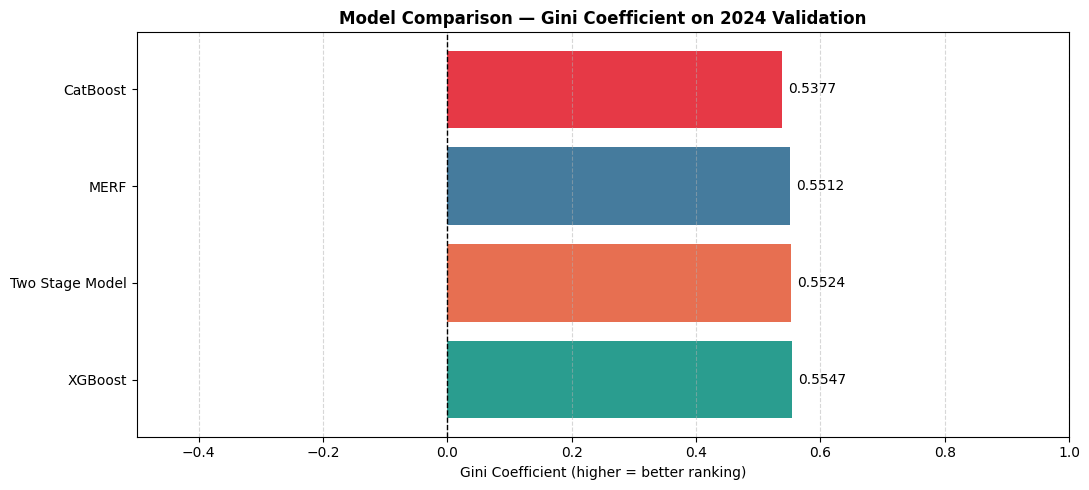

In [80]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
bars = ax.barh(df_summary["Model"], df_summary["Gini Coefficient"], color=colors)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Random Guess")

for bar, val in zip(bars, df_summary["Gini Coefficient"]):
    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Gini Coefficient (higher = better ranking)")
ax.set_title(
    "Model Comparison — Gini Coefficient on 2024 Validation", fontweight="bold"
)
ax.set_xlim(-0.5, 1.0)
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

In [81]:
df_mae = pd.DataFrame(gini_summary).sort_values("MAE")

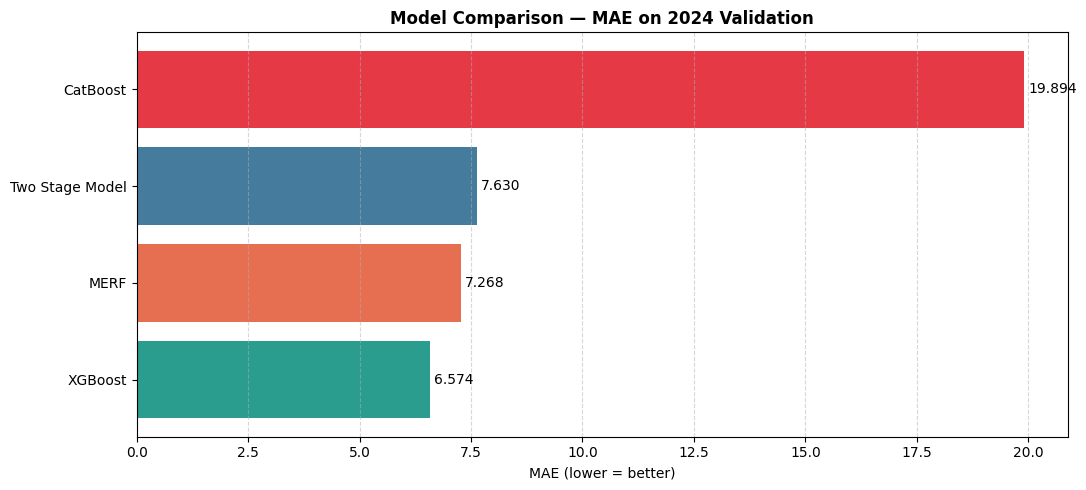

In [82]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2A9D8F", "#E76F51", "#457B9D", "#E63946", "#1D3557", "#9b59b6"]
ax.barh(df_mae["Model"], df_mae["MAE"], color=colors)

for i, (_, row) in enumerate(df_mae.iterrows()):
    ax.text(row["MAE"] + 0.1, i, f'{row["MAE"]:.3f}', va="center", fontsize=10)

ax.set_xlabel("MAE (lower = better)")
ax.set_title("Model Comparison — MAE on 2024 Validation", fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

fig.tight_layout()

we're choosing **XGBoost** as our final model

In [83]:
final_results = (
    test_df.with_columns(
        pl.Series(
            name="predicted_num_accidents", values=test_preds_xgb.round().astype(int)
        )
    )
    .with_columns(
        [
            (pl.col("predicted_num_accidents") / pl.col("total_pop") * 1000).alias(
                "pred_per_1k_residents"
            ),
            pl.col("predicted_num_accidents").rank(descending=True).alias("risk_rank"),
        ]
    )
    .sort("risk_rank")
)

In [84]:
print(final_results.sort("risk_rank"))

shape: (68, 57)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ gemeente   ┆ year   ┆ total_acci ┆ total_cyc ┆ … ┆ smoothed_ ┆ predicted ┆ pred_per_ ┆ risk_rank │
│ ---        ┆ ---    ┆ dents      ┆ ling_acci ┆   ┆ target    ┆ _num_acci ┆ 1k_reside ┆ ---       │
│ str        ┆ f64    ┆ ---        ┆ dents     ┆   ┆ ---       ┆ dents     ┆ nts       ┆ f64       │
│            ┆        ┆ f64        ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆           │
│            ┆        ┆            ┆ f64       ┆   ┆           ┆ i64       ┆ f64       ┆           │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Gent       ┆ 2025.0 ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 437       ┆ 1.602746  ┆ 1.0       │
│ Brugge     ┆ 2025.0 ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 223       ┆ 1.853961  ┆ 2.0       │
│ Leuven     ┆ 2025.0 ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 213       

In [85]:
final_results[["gemeente", "predicted_num_accidents"]]

gemeente,predicted_num_accidents
str,i64
"""Gent""",437
"""Brugge""",223
"""Leuven""",213
"""Kortrijk""",136
"""Mechelen""",133
…,…
"""Wemmel""",5
"""Sint-Pieters-Leeuw""",4
"""Heers""",3


In [86]:
final_results = final_results.to_pandas()

In [87]:
type_cols = [
    "prev_year_slick_accidents",
    "prev_year_carconflict_accidents",
    "prev_year_int_accidents",
]

In [88]:
means = final_results[type_cols].mean()
stds = final_results[type_cols].std().replace(0, 1)
z_scores = (final_results[type_cols] - means) / stds

In [89]:
striking_cols = z_scores.idxmax(axis=1)

In [90]:
name_map = {
    "prev_year_slick_accidents": "slick",
    "prev_year_carconflict_accidents": "car_conflict",
    "prev_year_int_accidents": "intersection",
}

In [91]:
final_results["most_frequent_type"] = striking_cols.map(name_map)

In [92]:
final_results.to_csv("data/final_results.csv", index=False)

In [93]:
(final_results["gemeente"] == "Beveren").sum()

np.int64(1)

In [94]:
final_results.columns

Index(['gemeente', 'year', 'total_accidents', 'total_cycling_accidents',
       'car_conflict', 'severity', 'slick', 'light', 'intersection',
       'school_peak', 'local_accidents', 'total_hourly_flow', 'avg_temp',
       'avg_precip', 'avg_mun_wind', 'bad_weather_ratio',
       'relative_sensor_age', 'avg_income_per_capita', 'prof_earner_ratio',
       'avg_employment_rate', 'inbound_push_ratio', 'total_pop',
       'pct_young_children', 'pct_school_kids', 'pct_uni_students',
       'pct_young_profs', 'pct_senior_profs', 'pct_seniors', 'pct_male',
       'pct_female', 'pct_belgian', 'pct_foreign', 'pct_single', 'pct_married',
       'pct_widowed', 'pct_divorced', 'accident_rate_per_flow',
       'accident_rate_per_capita', 'severity_index', 'prev_year_severe_count',
       'prev_year_dark_count', 'prev_year_local_accidents',
       'prev_year_school_accidents', 'prev_year_slick_accidents',
       'prev_year_carconflict_accidents', 'prev_year_int_accidents',
       'prev_year_total_ac

In [95]:
final_results.iloc[0]

gemeente                                   Gent
year                                     2025.0
total_accidents                             0.0
total_cycling_accidents                     0.0
car_conflict                                0.0
severity                                    0.0
slick                                       0.0
light                                       0.0
intersection                                0.0
school_peak                                 0.0
local_accidents                             0.0
total_hourly_flow                   4454.482422
avg_temp                              12.230687
avg_precip                             0.050635
avg_mun_wind                          11.941783
bad_weather_ratio                        0.0869
relative_sensor_age                         3.0
avg_income_per_capita              25795.208984
prof_earner_ratio                      0.626307
avg_employment_rate                    0.742867
inbound_push_ratio                     0